In [13]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r"C:\Users\Kübra\Documents\dataset.csv"

df = pd.read_csv(file_path)

print(df.head())
try:
    df = pd.read_csv(file_path)
    print("Veri seti başarıyla yüklendi.")
    print(f"Toplam {df.shape[0]} satır ve {df.shape[1]} sütun bulunmaktadır.")
except FileNotFoundError:
    print(f"HATA: '{file_path}' adında bir dosya bulunamadı.")
    print("Lütfen dosya adını ve yolunu kontrol edin.")

   Year LocationAbbr      LocationDesc GeographicLevel DataSource  \
0  2020           AK            Denali          County       NVSS   
1  2020           CA        California           State       NVSS   
2  2020           CO       Park County          County       NVSS   
3  2020           FL     Walton County          County       NVSS   
4  2020           GA  Whitfield County          County       NVSS   

                     Class                    Topic  Data_Value  \
0  Cardiovascular Diseases  Heart Disease Mortality       348.8   
1  Cardiovascular Diseases  Heart Disease Mortality       230.1   
2  Cardiovascular Diseases  Heart Disease Mortality       135.9   
3  Cardiovascular Diseases  Heart Disease Mortality       126.5   
4  Cardiovascular Diseases  Heart Disease Mortality       155.1   

          Data_Value_Unit                                    Data_Value_Type  \
0  per 100,000 population  Age-adjusted, Spatially Smoothed, 3-year Avera...   
1  per 100,000 populat

In [11]:
df_clean = df[df['GeographicLevel'] == 'County'].copy()
print(f"Sadece ilçe (County) verisi seçildi. Satır sayısı: {df_clean.shape[0]}")


cols_to_drop = [
    'Year', 'DataSource', 'Class', 'Topic', 'GeographicLevel',
    'Data_Value_Type', 'Data_Value_Unit', 'Data_Value_Footnote_Symbol',
    'Data_Value_Footnote', 'StratificationCategory1', 'StratificationCategory2',
    'TopicID', 'ClassID', 'TopicType',
    'LocationDesc' 
]

existing_cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_cols_to_drop)

df_clean = df_clean.rename(columns={
    'LocationAbbr': 'State',
    'LocationID': 'FIPS',          
    'Data_Value': 'Mortality_Rate',
    'Stratification1': 'Gender',
    'Stratification2': 'Race_Ethnicity'
})

print("Gereksiz sütunlar atıldı ve sütunlar yeniden adlandırıldı.")
df_clean.head()

Sadece ilçe (County) verisi seçildi. Satır sayısı: 77424
Gereksiz sütunlar atıldı ve sütunlar yeniden adlandırıldı.


,State,Mortality_Rate,Gender,Race_Ethnicity,FIPS,Y_lat,X_lon,Georeference
0,AK,348.8,Male,White,2068,63.678820,-149.960801,POINT (-149.9608012 63.67881971)
2,CO,135.9,Female,White,8093,39.115616,-105.708698,POINT (-105.7086982 39.11561621)
3,FL,126.5,Female,Asian,12131,30.655966,-86.157457,POINT (-86.15745736 30.65596581)
4,GA,155.1,Female,Hispanic,13313,34.803854,-84.962112,POINT (-84.96211184 34.80385386)
5,GA,NaN,Female,Asian,13299,31.051889,-82.420394,POINT (-82.4203935 31.05188914)


In [11]:
print("\nEksik Veri Kontrolü (Temizlemeden Önce):")
print(df_clean.isnull().sum())

df_clean.dropna(subset=['Mortality_Rate'], inplace=True)
print(f"\n'Mortality_Rate' sütununda eksik olan satırlar silindi. Yeni satır sayısı: {df_clean.shape[0]}")

print("\nVeri Tipi Kontrolü:")
df_clean.info()

if df_clean['Mortality_Rate'].dtype == 'object':
    df_clean['Mortality_Rate'] = pd.to_numeric(df_clean['Mortality_Rate'], errors='coerce')
    df_clean.dropna(subset=['Mortality_Rate'], inplace=True)


Eksik Veri Kontrolü (Temizlemeden Önce):
State             0
Mortality_Rate    0
Gender            0
Race_Ethnicity    0
FIPS              0
Y_lat             0
X_lon             0
Georeference      0
dtype: int64

'Mortality_Rate' sütununda eksik olan satırlar silindi. Yeni satır sayısı: 33431

Veri Tipi Kontrolü:
<class 'pandas.core.frame.DataFrame'>
Index: 33431 entries, 0 to 78790
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           33431 non-null  object 
 1   Mortality_Rate  33431 non-null  float64
 2   Gender          33431 non-null  object 
 3   Race_Ethnicity  33431 non-null  object 
 4   FIPS            33431 non-null  int64  
 5   Y_lat           33431 non-null  float64
 6   X_lon           33431 non-null  float64
 7   Georeference    33431 non-null  object 
dtypes: float64(3), int64(1), object(4)
memory usage: 2.3+ MB


In [12]:
df_clean['FIPS'] = df_clean['FIPS'].astype(str)

df_clean['FIPS'] = df_clean['FIPS'].str.zfill(5)

print("\nFIPS kodları 5 haneli metin formatına dönüştürüldü (örn: '01001').")
print(df_clean[['State', 'FIPS', 'Gender', 'Race_Ethnicity']].head())


FIPS kodları 5 haneli metin formatına dönüştürüldü (örn: '01001').
  State   FIPS   Gender Race_Ethnicity
0    AK  02068     Male          White
2    CO  08093   Female          White
3    FL  12131   Female          Asian
4    GA  13313   Female       Hispanic
6    IA  19093  Overall       Hispanic


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


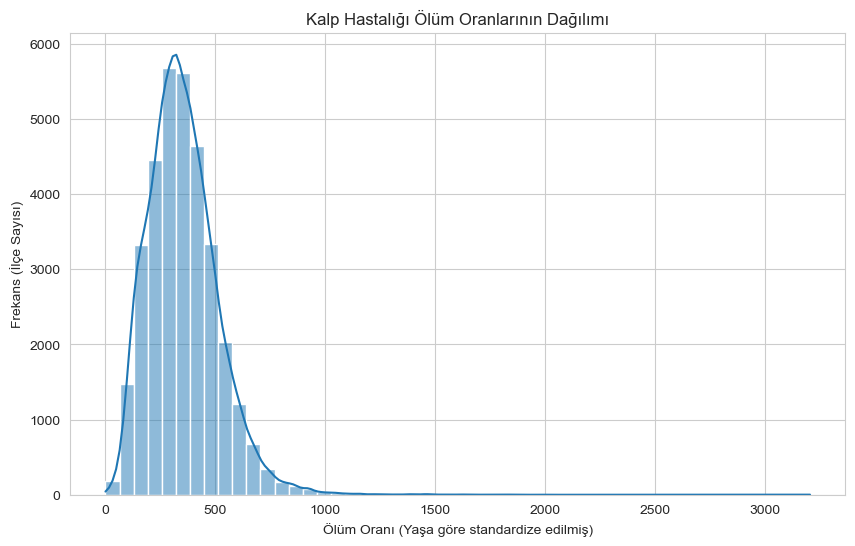

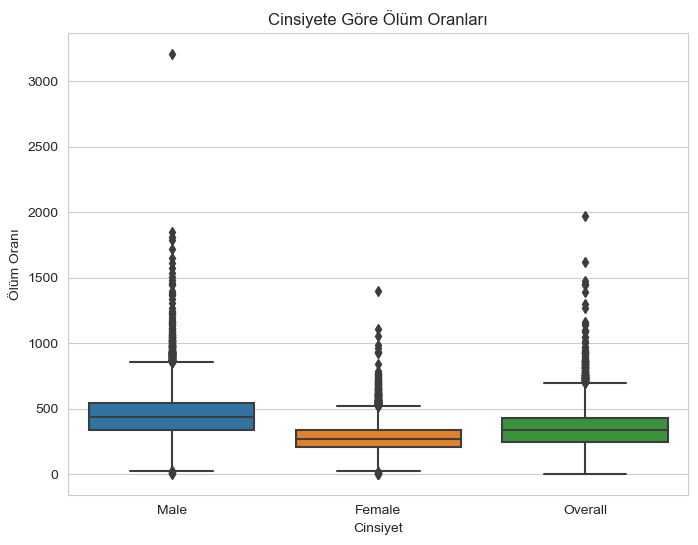

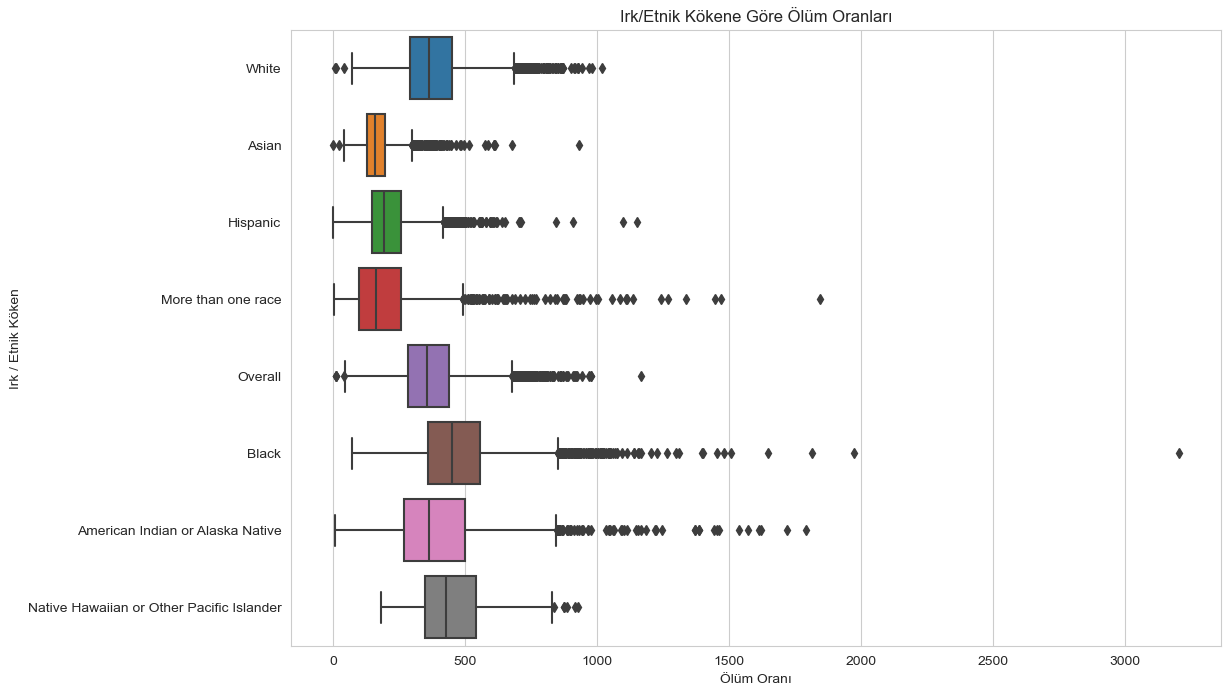

In [10]:
sns.set_style("whitegrid")

# 1. Hedef Değişkenin (Mortality_Rate) Dağılımı
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Mortality_Rate'], kde=True, bins=50)
plt.title('Kalp Hastalığı Ölüm Oranlarının Dağılımı')
plt.xlabel('Ölüm Oranı (Yaşa göre standardize edilmiş)')
plt.ylabel('Frekans (İlçe Sayısı)')
plt.show()

# 2. Cinsiyete Göre Ölüm Oranları
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='Gender', y='Mortality_Rate')
plt.title('Cinsiyete Göre Ölüm Oranları')
plt.xlabel('Cinsiyet')
plt.ylabel('Ölüm Oranı')
plt.show()

# 3. Etnik Köken/Irka Göre Ölüm Oranları
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_clean, y='Race_Ethnicity', x='Mortality_Rate', orient='h')
plt.title('Irk/Etnik Kökene Göre Ölüm Oranları')
plt.xlabel('Ölüm Oranı')
plt.ylabel('Irk / Etnik Köken')
plt.show()

In [8]:
import pandas as pd
import sys
import openpyxl

files_to_check = [r"C:\Users\Kübra\Documents\Poverty2023.xlsx",r"C:\Users\Kübra\Documents\Education2023.xlsx", r"C:\Users\Kübra\Documents\Unemployment2023.xlsx"]

for file in files_to_check:
    
    try:
        xls = pd.ExcelFile(file)
        sheet_names = xls.sheet_names
        print(f"Bulunan Sekme Adları: {sheet_names}")
        
    
        data_sheet_name = None
        for name in sheet_names:
            if "description" not in name.lower() and "readme" not in name.lower():
                data_sheet_name = name
                print(f"Veri sekmesi olarak '{data_sheet_name}' seçildi.")
                break
        
        if not data_sheet_name:
            print("Veri sekmesi bulunamadı.")

        print(f"\n'{data_sheet_name}' sekmesinin ilk 10 satırı (HAM GÖRÜNÜM):")
        df_preview = pd.read_excel(xls, sheet_name=data_sheet_name, header=None, nrows=10)
        print(df_preview)
        
       
        try:
            header_row_index = 4 
            df_cols = pd.read_excel(xls, sheet_name=data_sheet_name, header=header_row_index)
            print(f"\n'{data_sheet_name}' (Başlık Satırı: {header_row_index}) Sütun Listesi:")
            for col in df_cols.columns:
                print(col)
        except Exception as e:
            print(f"Başlıklar okunurken hata: {e}. header_row_index'i kontrol edin.")

    except FileNotFoundError:
        print(f"HATA: '{file}' dosyası bulunamadı. İndirip adını doğru yazdığınızdan emin olun.")
    except Exception as e:
        print(f"Bir hata oluştu: {e}")

Bulunan Sekme Adları: ['Poverty Data 2023', 'Variable Descriptions']
Veri sekmesi olarak 'Poverty Data 2023' seçildi.

'Poverty Data 2023' sekmesinin ilk 10 satırı (HAM GÖRÜNÜM):
                                                  0      1               2   \
0  Poverty estimates for United States, States, a...    NaN             NaN   
1  Source: U.S. Department of Commerce, Bureau of...    NaN             NaN   
2  Poverty status is determined at the family lev...    NaN             NaN   
3  This table was prepared by USDA, Economic Rese...    NaN             NaN   
4                                          FIPS_Code  Stabr       Area_Name   
5                                              00000     US   United States   
6                                              01000     AL         Alabama   
7                                              01001     AL  Autauga County   
8                                              01003     AL  Baldwin County   
9                              

In [13]:
#  BÖLÜM 2: SOSYOEKONOMİK VERİLERİ YÜKLEME VE BİRLEŞTİRME ---
print("\nBölüm 2: Sosyoekonomik veriler yükleniyor...")

try:
    #  2.1: GELİR (INCOME) VERİSİ
    INCOME_DOSYA_ADI = r"C:\Users\Kübra\Documents\Unemployment2023.xlsx"
    INCOME_SEKME_ADI = "Unemployment Med HH Income"
    INCOME_BASLIK_SATIRI = 4 
    
    df_income = pd.read_excel(INCOME_DOSYA_ADI, sheet_name=INCOME_SEKME_ADI, header=INCOME_BASLIK_SATIRI, dtype={'FIPS_Code': str})
    INCOME_SUTUNLARI = {
        'FIPS_Code': 'FIPS',
        'Median_Household_Income_2022': 'Median_Income_2022' 
    }
    df_income = df_income[list(INCOME_SUTUNLARI.keys())].copy()
    df_income.rename(columns=INCOME_SUTUNLARI, inplace=True)
    df_income['FIPS'] = df_income['FIPS'].str.zfill(5)
    print(f"'{INCOME_DOSYA_ADI}' yüklendi ve işlendi.")

    #  2.2: EĞİTİM (EDUCATION) VERİSİ
    EDUCATION_DOSYA_ADI = r"C:\Users\Kübra\Documents\Education2023.xlsx"
    EDUCATION_SEKME_ADI = "Education 1970 to 2023"
    EDUCATION_BASLIK_SATIRI = 3 
    
    df_edu = pd.read_excel(EDUCATION_DOSYA_ADI, sheet_name=EDUCATION_SEKME_ADI, header=EDUCATION_BASLIK_SATIRI, dtype={'FIPS Code': str})
    EDUCATION_SUTUNLARI = {
        'FIPS Code': 'FIPS', 
        "Percent of adults with a bachelor's degree or higher, 2019-23": 'Edu_Bach_Pct_2019-23'
    }
    df_edu = df_edu[list(EDUCATION_SUTUNLARI.keys())].copy()
    df_edu.rename(columns=EDUCATION_SUTUNLARI, inplace=True)
    df_edu['FIPS'] = df_edu['FIPS'].str.zfill(5)
    print(f"'{EDUCATION_DOSYA_ADI}' yüklendi ve işlendi.")

    #  2.3: YOKSULLUK (POVERTY) VERİSİ 
    POVERTY_DOSYA_ADI = r"C:\Users\Kübra\Documents\Poverty2023.xlsx"
    POVERTY_SEKME_ADI = "Poverty Data 2023"
    POVERTY_BASLIK_SATIRI = 4 
    
    df_poverty = pd.read_excel(POVERTY_DOSYA_ADI, sheet_name=POVERTY_SEKME_ADI, header=POVERTY_BASLIK_SATIRI, dtype={'FIPS_Code': str})
    POVERTY_SUTUNLARI = {
        'FIPS_Code': 'FIPS',
        'PCTPOVALL_2023': 'Poverty_Pct_2023' 
    }
    df_poverty = df_poverty[list(POVERTY_SUTUNLARI.keys())].copy()
    df_poverty.rename(columns=POVERTY_SUTUNLARI, inplace=True)
    df_poverty['FIPS'] = df_poverty['FIPS'].str.zfill(5)
    print(f"'{POVERTY_DOSYA_ADI}' yüklendi ve işlendi.")

except FileNotFoundError as e:
    print(f"HATA: Dosya bulunamadı -> {e}. Lütfen dosya adlarını kontrol edin.")
    raise SystemExit("Script durduruldu.")
except KeyError as e:
    print(f"HATA: Sütun adı bulunamadı -> {e}.")
    print("Bir sütun adında yazım hatası olabilir, lütfen kodu kontrol edin.")
    raise SystemExit("Script durduruldu.")
except Exception as e:
    print(f"Genel bir hata oluştu: {e}")
    raise SystemExit("Script durduruldu.")


#  BÖLÜM 3: TÜM VERİLERİ BİRLEŞTİRME VE KAYDETME
print("\nBölüm 3: Tüm veriler birleştiriliyor...")

df_socio_merged = pd.merge(df_income, df_edu, on='FIPS', how='outer')
df_socio_merged = pd.merge(df_socio_merged, df_poverty, on='FIPS', how='outer')

df_final_merged = pd.merge(df_clean, df_socio_merged, on='FIPS', how='left')

print("Birleştirme tamamlandı. Son kontroller yapılıyor...")

print(f"Birleştirmeden önce satır sayısı: {df_clean.shape[0]}")
print(f"Birleştirmeden sonra satır sayısı: {df_final_merged.shape[0]}")


original_rows = df_final_merged.shape[0]
df_final_merged.dropna(inplace=True)
final_rows = df_final_merged.shape[0]

print(f"Sosyoekonomik verisi eksik olan {original_rows - final_rows} satır silindi.")
print(f"Veri setinin son boyutu: {df_final_merged.shape}")


Bölüm 2: Sosyoekonomik veriler yükleniyor...
'C:\Users\Kübra\Documents\Unemployment2023.xlsx' yüklendi ve işlendi.
'C:\Users\Kübra\Documents\Education2023.xlsx' yüklendi ve işlendi.
'C:\Users\Kübra\Documents\Poverty2023.xlsx' yüklendi ve işlendi.

Bölüm 3: Tüm veriler birleştiriliyor...
Birleştirme tamamlandı. Son kontroller yapılıyor...
Birleştirmeden önce satır sayısı: 33431
Birleştirmeden sonra satır sayısı: 33431
Sosyoekonomik verisi eksik olan 401 satır silindi.
Veri setinin son boyutu: (33030, 11)


In [14]:

# FAZ 2 İÇİN FİNAL VERİ SETİNİ KAYDETME
output_file = "tum_veriler_temiz_birlesmis.csv"
df_final_merged.to_csv(output_file, index=False)

print(f"\n--- FAZ 1 TAMAMLANDI ---")
print(f"Tüm temizlenmiş ve birleştirilmiş veriler '{output_file}' olarak kaydedildi.")
print(f"Tüm grup üyeleri artık Faz 2 (Bireysel Çalışma) için bu '{output_file}' dosyasını kullanabilir.")


--- FAZ 1 TAMAMLANDI ---
Tüm temizlenmiş ve birleştirilmiş veriler 'tum_veriler_temiz_birlesmis.csv' olarak kaydedildi.
Tüm grup üyeleri artık Faz 2 (Bireysel Çalışma) için bu 'tum_veriler_temiz_birlesmis.csv' dosyasını kullanabilir.


'tum_veriler_temiz_birlesmis.csv' dosyası başarıyla yüklendi. Başlangıç boyutu: (33030, 11)

Kategorik değişkenler One-Hot Encoding ile işlendi.
Başlangıç Öznitelik Sayısı (X): 5
Sayısal öznitelikler başarıyla ölçeklendi (StandardScaler).


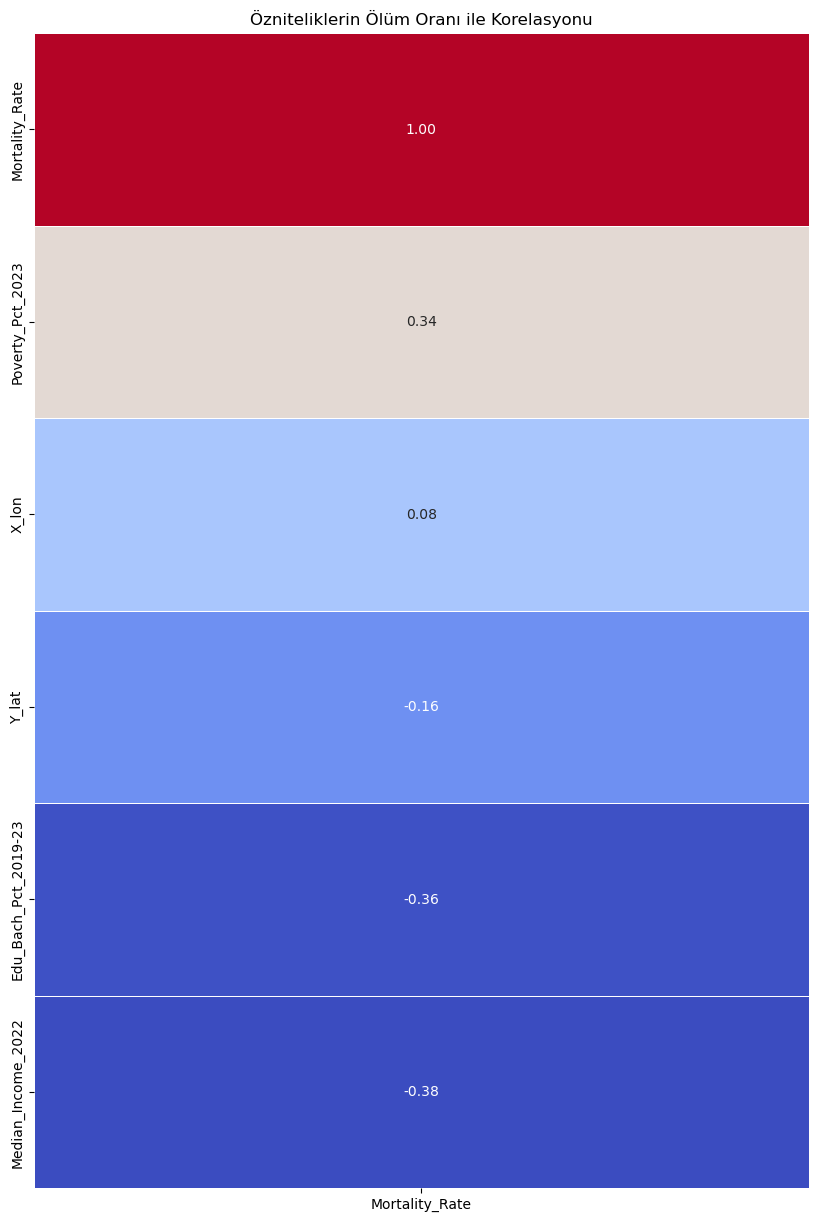

   Otomatik olarak en iyi 5 öznitelik seçildi: ['Poverty_Pct_2023', 'X_lon', 'Y_lat', 'Edu_Bach_Pct_2019-23', 'Median_Income_2022']

Korelasyon Eşiği (0.4) kullanılarak seçilen öznitelik sayısı: 5
Seçilen öznitelikler: ['Poverty_Pct_2023', 'X_lon', 'Y_lat', 'Edu_Bach_Pct_2019-23', 'Median_Income_2022']


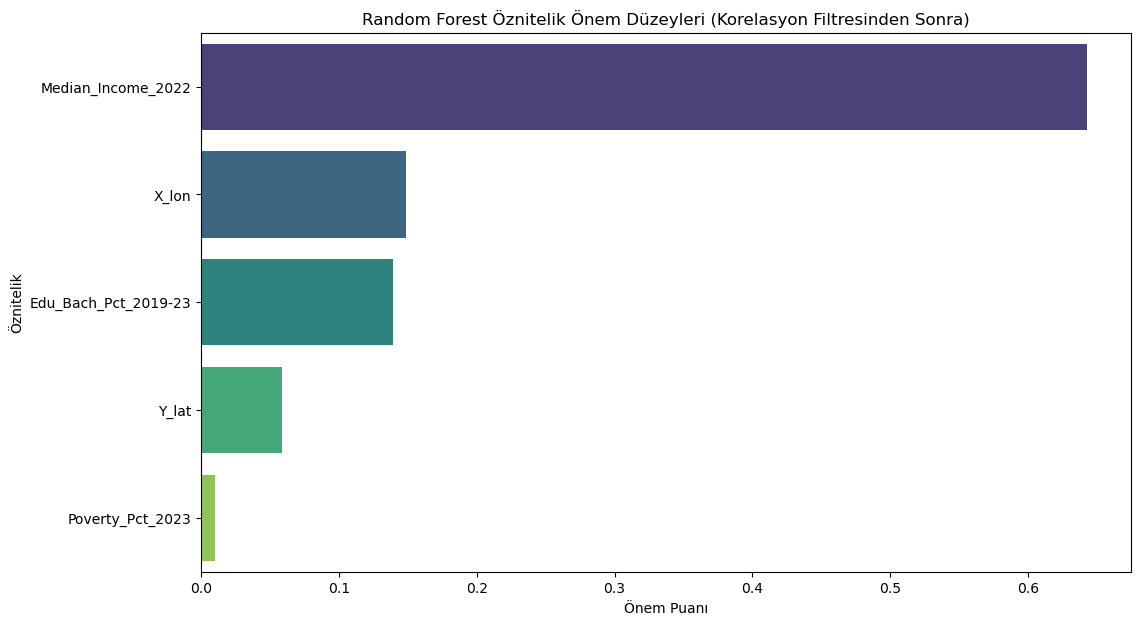

Nihai Öznitelik Kümesi: ['Median_Income_2022', 'X_lon', 'Edu_Bach_Pct_2019-23', 'Y_lat', 'Poverty_Pct_2023']
X_final boyutu: (33030, 5)

--- FAZ 2 TAMAMLANDI. FAZ 3'E GEÇİLİYOR ---
Eğitim Kümesi (X_train) Boyutu: (24772, 5)
Test Kümesi (X_test) Boyutu: (8258, 5)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

#  1. Veri Setini Yükleme 
FILE_NAME = "tum_veriler_temiz_birlesmis.csv"
try:
    df = pd.read_csv(FILE_NAME)
    print(f"'{FILE_NAME}' dosyası başarıyla yüklendi. Başlangıç boyutu: {df.shape}")
except FileNotFoundError:
    print(f"HATA: '{FILE_NAME}' bulunamadı. Lütfen Faz 1'de oluşturduğunuz dosya adını kontrol edin.")
    raise SystemExit()

#  2. Kategorik Değişkenleri Hazırlama (One-Hot Encoding) 

CATEGORICAL_COLS = ['Gender', 'Race_Ethnicity']
df_encoded = pd.get_dummies(df, columns=CATEGORICAL_COLS, drop_first=True)
print("\nKategorik değişkenler One-Hot Encoding ile işlendi.")

#  3. Bağımlı ve Bağımsız Değişkenleri Ayırma ve Temizlik 

COLS_TO_DROP_FINALLY = ['FIPS', 'State']

X = df_encoded.drop(columns=['Mortality_Rate'] + COLS_TO_DROP_FINALLY, errors='ignore')
y = df_encoded['Mortality_Rate']

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
X = X[numeric_cols] 

print(f"Başlangıç Öznitelik Sayısı (X): {X.shape[1]}")

#  4. Veri Ölçekleme (StandardScaler) 

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)
print("Sayısal öznitelikler başarıyla ölçeklendi (StandardScaler).")


y_reset = y.reset_index(drop=True)
X_scaled_reset = X_scaled.reset_index(drop=True)

correlation_matrix = pd.concat([X_scaled_reset, y_reset], axis=1).corr()
target_corr = correlation_matrix['Mortality_Rate'].sort_values(ascending=False)

plt.figure(figsize=(10, 15))
sns.heatmap(target_corr.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar=False)
plt.title('Özniteliklerin Ölüm Oranı ile Korelasyonu')
plt.show() # 

CORRELATION_THRESHOLD = 0.4 
high_corr_features = target_corr[abs(target_corr) > CORRELATION_THRESHOLD].index.tolist()

if 'Mortality_Rate' in high_corr_features:
    high_corr_features.remove('Mortality_Rate')

if len(high_corr_features) == 0:
    high_corr_features = target_corr.index[1:6].tolist() 
    print(f"   Otomatik olarak en iyi 5 öznitelik seçildi: {high_corr_features}")


X_filtered = X_scaled[high_corr_features]
print(f"\nKorelasyon Eşiği ({CORRELATION_THRESHOLD}) kullanılarak seçilen öznitelik sayısı: {X_filtered.shape[1]}")
print("Seçilen öznitelikler:", high_corr_features)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_filtered, y)

feature_importances = pd.Series(rf_model.feature_importances_, index=X_filtered.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Random Forest Öznitelik Önem Düzeyleri (Korelasyon Filtresinden Sonra)')
plt.xlabel('Önem Puanı')
plt.ylabel('Öznitelik')
plt.show()


N_BEST_FEATURES = 10 
final_features = feature_importances.head(N_BEST_FEATURES).index.tolist()

X_final = X_scaled[final_features] 
print("Nihai Öznitelik Kümesi:", final_features)
print(f"X_final boyutu: {X_final.shape}")


X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.25, random_state=42 
)

print("\n--- FAZ 2 TAMAMLANDI. FAZ 3'E GEÇİLİYOR ---")
print(f"Eğitim Kümesi (X_train) Boyutu: {X_train.shape}")
print(f"Test Kümesi (X_test) Boyutu: {X_test.shape}")


Veri Hazır. Toplam Özellik Sayısı: 14
    -> Seçilen Özellikler: ['Y_lat', 'X_lon', 'Median_Income_2022', 'Edu_Bach_Pct_2019-23', 'Poverty_Pct_2023', 'Gender_Male', 'Gender_Overall', 'Race_Ethnicity_Asian', 'Race_Ethnicity_Black', 'Race_Ethnicity_Hispanic', 'Race_Ethnicity_More than one race', 'Race_Ethnicity_Native Hawaiian or Other Pacific Islander', 'Race_Ethnicity_Overall', 'Race_Ethnicity_White']
    -> Seçilen Özellikler: ['Y_lat', 'Median_Income_2022', 'Edu_Bach_Pct_2019-23', 'Poverty_Pct_2023', 'Gender_Male', 'Race_Ethnicity_Asian', 'Race_Ethnicity_Black', 'Race_Ethnicity_Hispanic', 'Race_Ethnicity_More than one race', 'Race_Ethnicity_White']

--- PERFORMANS TABLOSU ---
                  Senaryo                 Model  Özellik Sayısı  Accuracy  \
0          Tüm Özellikler   Logistic Regression              14  0.841205   
1          Tüm Özellikler  Gaussian Naive Bayes              14  0.733727   
2  Top 15 Özellik (ANOVA)   Logistic Regression              14  0.841205   
3  T

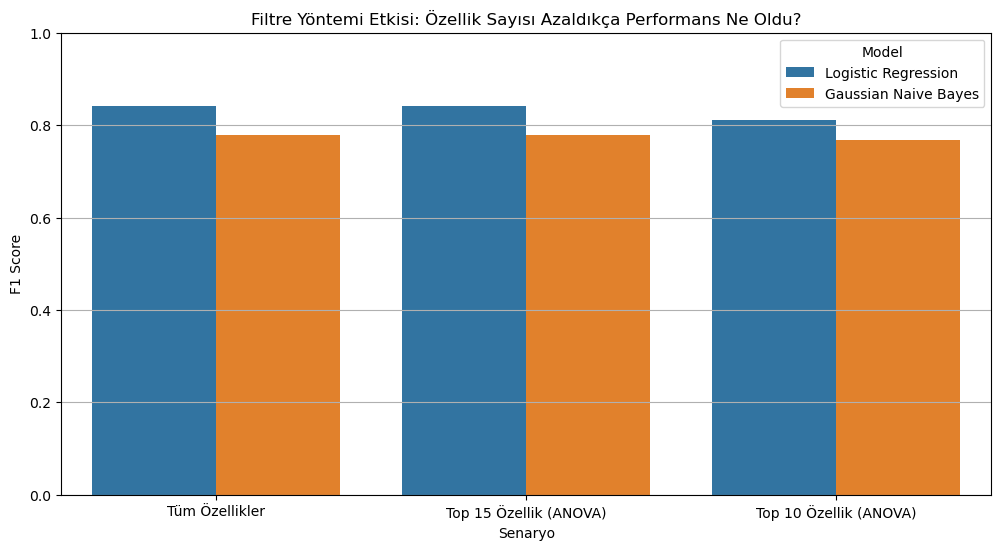

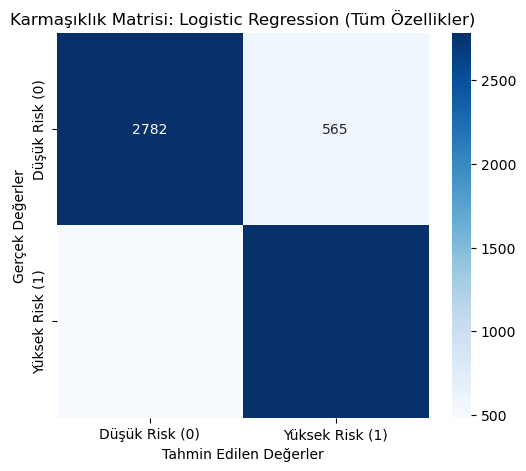

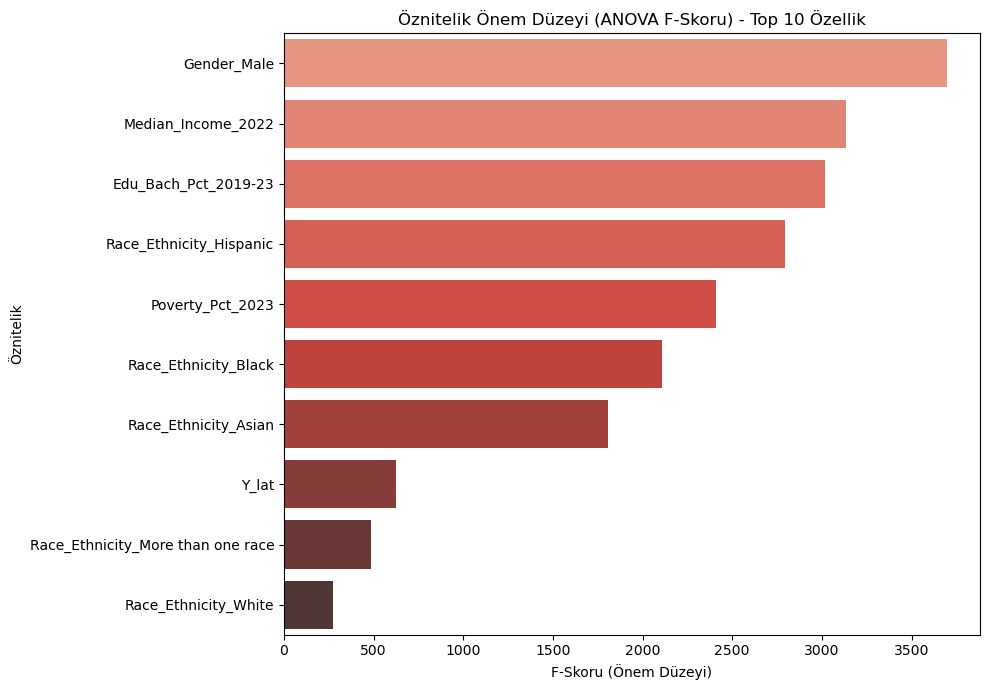


--- FAZ 3 TAMAMLANDI: Tüm Görsel Çıktılar Üretildi ---


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Sklearn Kütüphaneleri
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# --- I. VERİ HAZIRLIĞI ---
df = pd.read_csv("tum_veriler_temiz_birlesmis.csv")

COLS_TO_DROP_INITIAL = ['State', 'FIPS', 'Georeference'] 
df_model = df.drop(columns=COLS_TO_DROP_INITIAL, errors='ignore')
threshold = df_model['Mortality_Rate'].median()
df_model['Risk_Class'] = (df_model['Mortality_Rate'] > threshold).astype(int)
df_model = df_model.drop(columns=['Mortality_Rate']) 
df_encoded = pd.get_dummies(df_model, drop_first=True)
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

X = df_encoded.drop(columns=['Risk_Class'])
y = df_encoded['Risk_Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"\nVeri Hazır. Toplam Özellik Sayısı: {X_train_scaled_df.shape[1]}")


# --- II. DENEY KURULUMU VE MODELLER ---
results = []
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gaussian Naive Bayes": GaussianNB()
}

scenarios = [
    ("Tüm Özellikler", "all"),
    ("Top 15 Özellik (ANOVA)", 14), 
    ("Top 10 Özellik (ANOVA)", 10) 
]

best_model_results = {} 
f_scores_for_plot = None 


for scenario_name, k_val in scenarios:
    
    # ÖZELLİK SEÇİMİ (FILTER METHOD - ANOVA)
    if k_val == "all":
        X_tr_final = X_train_scaled_df
        X_te_final = X_test_scaled_df
        selected_features = X.columns.tolist()
    else:
        selector = SelectKBest(score_func=f_classif, k=k_val)
        selector.fit(X_train_scaled_df, y_train)
        
        cols_idxs = selector.get_support(indices=True)
        X_tr_final = X_train_scaled_df.iloc[:, cols_idxs]
        X_te_final = X_test_scaled_df.iloc[:, cols_idxs]
        
        selected_features = X_tr_final.columns.tolist()
        print(f"    -> Seçilen Özellikler: {selected_features}")
        
        if scenario_name == "Top 10 Özellik (ANOVA)":
            f_scores = selector.scores_[cols_idxs]
            f_scores_for_plot = pd.DataFrame({
                'Feature': selected_features, 
                'F-Score': f_scores
            }).sort_values(by='F-Score', ascending=False)


    for model_name, model in models.items():
        start_time = time.time()
        
        model.fit(X_tr_final, y_train)
        y_pred = model.predict(X_te_final)
        
        elapsed = time.time() - start_time
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results.append({
            "Senaryo": scenario_name,
            "Model": model_name,
            "Özellik Sayısı": len(selected_features),
            "Accuracy": acc,
            "F1 Score": f1,
            "Süre (sn)": elapsed
        })
        
        if f1 > best_model_results.get('F1 Score', 0):
            best_model_results = {
                "F1 Score": f1,
                "y_pred": y_pred,
                "model_name": model_name,
                "scenario_name": scenario_name
            }

# --- III. SONUÇLARIN RAPORLANMASI VE GÖRSELLEŞTİRME ---
df_results = pd.DataFrame(results)

print("\n--- PERFORMANS TABLOSU ---")
print(df_results)


# 1. F1 SCORE KARŞILAŞTIRMA GRAFİĞİ
plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x="Senaryo", y="F1 Score", hue="Model")
plt.title("Filtre Yöntemi Etkisi: Özellik Sayısı Azaldıkça Performans Ne Oldu?")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

# 2. EN İYİ MODEL İÇİN KARMAŞIKLIK MATRİSİ (CONFUSION MATRIX)
cm = confusion_matrix(y_test, best_model_results['y_pred'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Düşük Risk (0)', 'Yüksek Risk (1)'], 
            yticklabels=['Düşük Risk (0)', 'Yüksek Risk (1)'])
plt.title(f"Karmaşıklık Matrisi: {best_model_results['model_name']} ({best_model_results['scenario_name']})")
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

# 3. ÖZELLİK ÖNEM GRAFİĞİ (ANOVA F-SKORU) - Sadece Top 10 için
if f_scores_for_plot is not None:
    plt.figure(figsize=(10, 7))
    sns.barplot(x='F-Score', y='Feature', data=f_scores_for_plot, palette='Reds_d')
    plt.title(f"Öznitelik Önem Düzeyi (ANOVA F-Skoru) - Top 10 Özellik")
    plt.xlabel("F-Skoru (Önem Düzeyi)")
    plt.ylabel("Öznitelik")
    plt.tight_layout() 
    plt.show()
else:
    print("\n UYARI: Özellik Önemi Grafiği (F-Score) sadece 'Top 10 Özellik (ANOVA)' senaryosu için çizdirildi.")

print("\n--- FAZ 3 TAMAMLANDI: Tüm Görsel Çıktılar Üretildi ---")